In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix

===============================================

ENTRENAMIENTO SVM

===============================================

In [3]:
# 1.Cargar y preparar los datos
data = load_breast_cancer()
X, y = data.data, data.target

# Estandarizacion
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Reducir a 2 dimensiones usando PCA
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

# Separar los datos en conjuntos de entrenamiento y prueba (70% entrenamiento, 30% prueba)
X_train, X_test, y_train, y_test = train_test_split(X_pca, y, test_size=0.3, random_state=42)

# 2. Entrenamiento y evaluación de modelos SVM con diferentes hiperparámetros
hyperparams = [
    {'C': 0.1, 'kernel': 'linear'},
    {'C': 5, 'kernel': 'linear'},
    {'C': 10, 'kernel': 'linear'}
]

models = []
scores = []
conf_matrices = []

for params in hyperparams:
    svm = SVC(**params, random_state=42)
    svm.fit(X_train, y_train)
    y_pred = svm.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    cm = confusion_matrix(y_test, y_pred)
    
    models.append((svm, params))
    scores.append(acc)
    conf_matrices.append(cm)

===============================================

VISUALIZACION DE RESULTADOS

===============================================

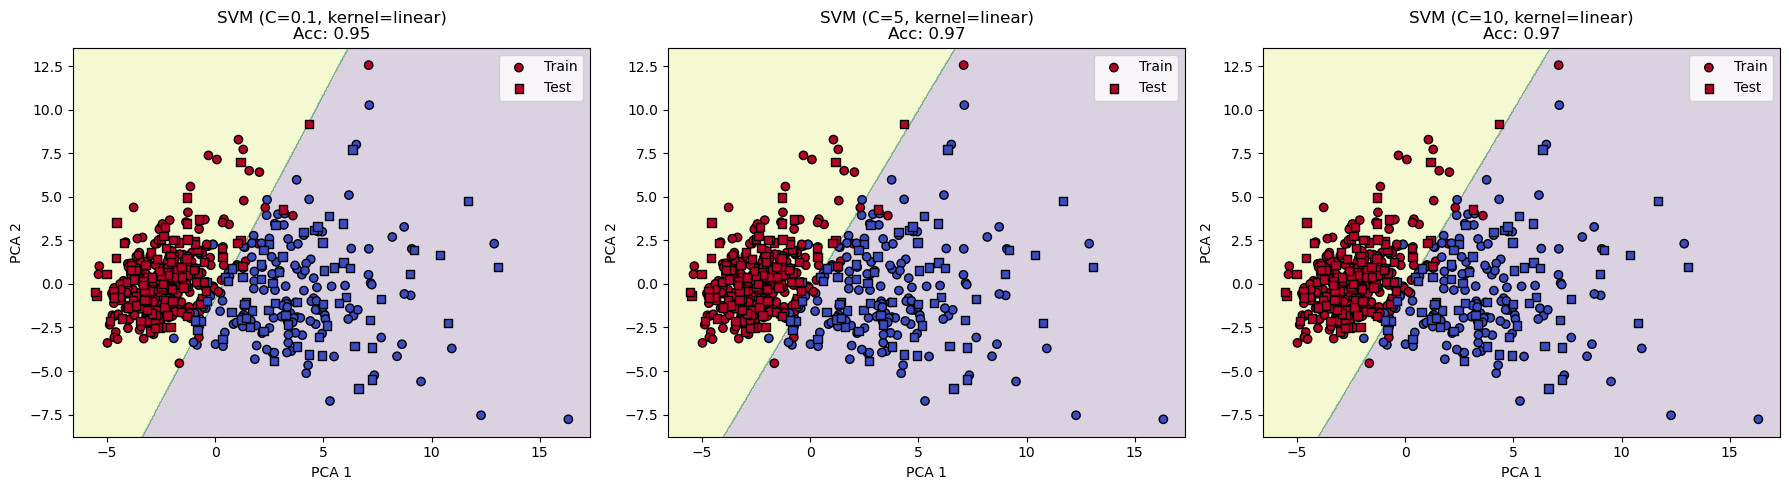

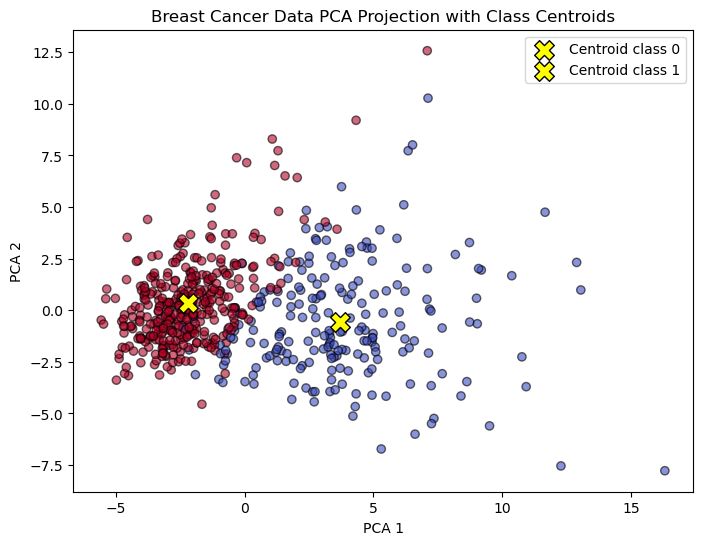

In [4]:
# 3a. Fronteras de decisión y puntos de entrenamiento/prueba
fig, axes = plt.subplots(1, len(models), figsize=(18, 5))

# Crear una malla para las fronteras de decisión
x_min, x_max = X_pca[:, 0].min() - 1, X_pca[:, 0].max() + 1
y_min, y_max = X_pca[:, 1].min() - 1, X_pca[:, 1].max() + 1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 500),
                     np.linspace(y_min, y_max, 500))
grid_points = np.c_[xx.ravel(), yy.ravel()]

for idx, (svm, params) in enumerate(models):
    ax = axes[idx]
    # Prediccion de la malla
    Z = svm.predict(grid_points).reshape(xx.shape)
    ax.contourf(xx, yy, Z, alpha=0.2)
    
    # Graficarpuntos de entrenamiento y prueba
    ax.scatter(X_train[:, 0], X_train[:, 1], c=y_train, cmap='coolwarm', edgecolors='k', marker='o', label='Train')
    ax.scatter(X_test[:, 0], X_test[:, 1], c=y_test, cmap='coolwarm', edgecolors='k', marker='s', label='Test')
    
    ax.set_title(f"SVM (C={params['C']}, kernel={params['kernel']})\nAcc: {scores[idx]:.2f}")
    ax.set_xlabel('PCA 1')
    ax.set_ylabel('PCA 2')
    ax.legend(loc='upper right')

plt.tight_layout()

# 3b. Distribución de clases y centroides
fig, ax = plt.subplots(figsize=(8, 6))
# Graficas los puntos de datos en el espacio PCA
ax.scatter(X_pca[:, 0], X_pca[:, 1], c=y, cmap='coolwarm', edgecolors='k', alpha=0.6)
# Calcular y graficar los centroides de cada clase
centroids = []
for label in np.unique(y):
    mean_point = X_pca[y == label].mean(axis=0)
    centroids.append(mean_point)
    ax.scatter(mean_point[0], mean_point[1], c='yellow', edgecolors='k', s=200, marker='X', label=f"Centroid class {label}")

ax.set_title('Breast Cancer Data PCA Projection with Class Centroids')
ax.set_xlabel('PCA 1')
ax.set_ylabel('PCA 2')
ax.legend()
plt.show()

===============================================

Analisis de Resultados

===============================================

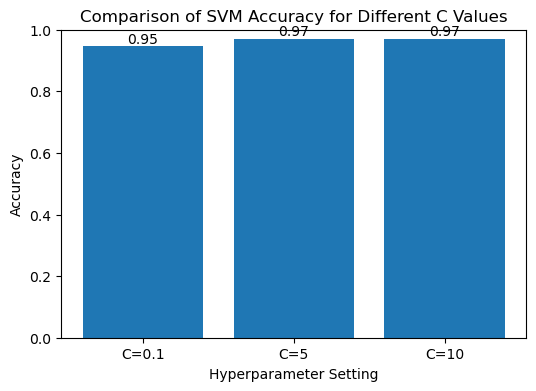

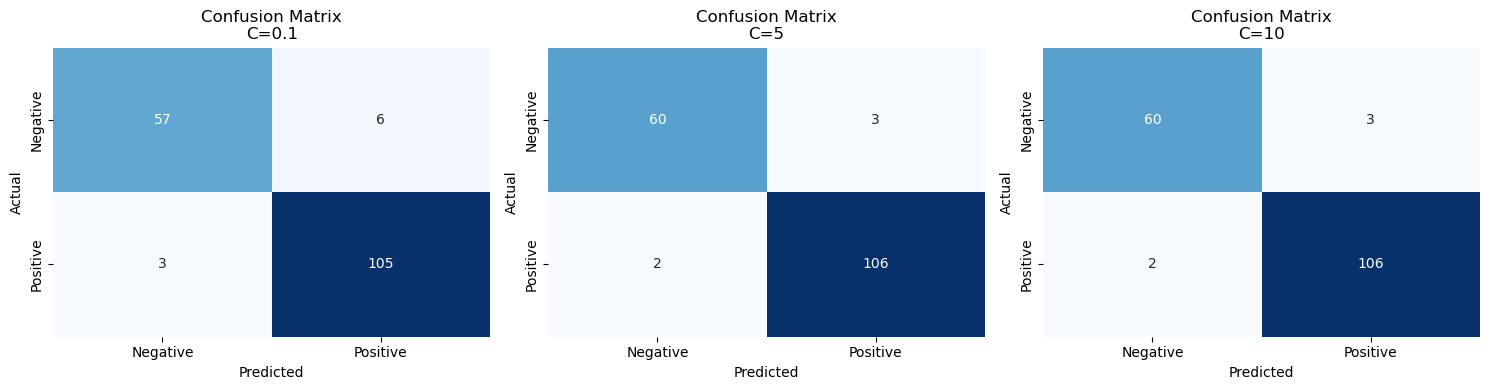

In [5]:
# Gráfica de precisión vs. parámetro C
fig, ax = plt.subplots(figsize=(6, 4))
param_labels = [f"C={p['C']}" for p in hyperparams]
ax.bar(param_labels, scores)
ax.set_title('Comparison of SVM Accuracy for Different C Values')
ax.set_xlabel('Hyperparameter Setting')
ax.set_ylabel('Accuracy')
ax.set_ylim(0, 1)

for i, acc in enumerate(scores):
    ax.text(i, acc, f"{acc:.2f}", ha='center', va='bottom', fontsize=10)
plt.show()

# Graficar cada matriz de confusión como heatmap
num_matrices = len(conf_matrices)
fig, axes = plt.subplots(1, num_matrices, figsize=(5 * num_matrices, 4))

if num_matrices == 1:
    axes = [axes]

for ax, cm, param in zip(axes, conf_matrices, hyperparams):
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax, cbar=False)
    ax.set_title(f"Confusion Matrix\nC={param['C']}")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
    ax.set_xticklabels(['Negative', 'Positive'])
    ax.set_yticklabels(['Negative', 'Positive'])

plt.tight_layout()
plt.show()